In [122]:
import os
import glob
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

import torch
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchsummary import summary
import torch.optim as optim

from lib.dataset.dataloader import SICDataLoader, _load_sic, _load_amsr2, _load_pair, _extract_statistics_worker
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm


In [ ]:
# dfs = []
# for year in range(2014, 2025):
#     csv_path = f'/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_{year}.csv'
#     if not os.path.exists(csv_path): #2020, 2021, 2022
#         continue

#     df = pd.read_csv(csv_path)
#     dfs.append(df)

# df_stats = pd.concat(dfs, ignore_index=True)
# df_stats.to_csv('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_all_year.csv', index=False)


[2020] Missing file: /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_2020.csv
[2021] Missing file: /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_2021.csv
[2022] Missing file: /dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_2022.csv


In [123]:
sic_loader = SICDataLoader(
    data_dirs=['/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2','/dmidata/projects/asip-cms/reproc'],
    shuffle=False,
    date_pattern=r'(\d{8})[T]\d{6}',
    years = [2014]
)


Manually loading files

In [124]:
amsr2_file = sic_loader.get_matched_pairs_info()[0]['amsr2_files'][0]
# amsr2_file = "\\\\?\\" + os.path.abspath(Path(amsr2_file).as_posix())

sic_file = sic_loader.get_matched_pairs_info()[0]['sic_files'][0]
# sic_file = "\\\\?\\" + os.path.abspath(Path(sic_file).as_posix())

print(f"AMSR2 file: {amsr2_file}")
print(f"SIC file: {sic_file}")

AMSR2 file: /dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2014/11/02/AMSR2_S1A_EW_GRDM_1SDH_20141102T143158_20141102T143305_003104_0038F5_556D.nc
SIC file: /dmidata/projects/asip-cms/reproc/2014/11/02/S1A_EW_GRDM_1SDH_20141102T143158_20141102T143305_003104_0038F5_556D_SIC.tiff


In [125]:
ds_amsr = _load_amsr2(amsr2_file, sic_loader.date_pattern)
# print(ds_amsr)
ds_sic = _load_sic(sic_file, sic_loader.date_pattern)
# print(ds_sic)

In [ ]:
# ds_amsr = xr.load_dataset(amsr2_file, engine='netcdf4')

In [38]:
ds_amsr

<xarray.Dataset> Size: 5MB
Dimensions:             (dim_0: 223, dim_1: 207)
Dimensions without coordinates: dim_0, dim_1
Data variables: (12/15)
    btemp_6.9h          (dim_0, dim_1) float64 369kB 145.0 143.9 ... 233.9 233.9
    btemp_6.9v          (dim_0, dim_1) float64 369kB 199.5 198.9 ... 258.2 258.3
    btemp_7.3h          (dim_0, dim_1) float64 369kB 146.7 145.6 ... 233.9 234.0
    btemp_7.3v          (dim_0, dim_1) float64 369kB 201.6 201.0 ... 258.6 258.7
    btemp_10.7h         (dim_0, dim_1) float64 369kB 144.2 143.4 ... 222.7 222.7
    btemp_10.7v         (dim_0, dim_1) float64 369kB 201.7 201.3 ... 254.4 254.5
    ...                  ...
    btemp_23.8v         (dim_0, dim_1) float64 369kB 211.7 212.0 ... 231.5 231.7
    btemp_36.5h         (dim_0, dim_1) float64 369kB 166.3 170.3 ... 196.4 196.8
    btemp_36.5v         (dim_0, dim_1) float64 369kB 219.5 220.7 ... 216.2 216.8
    btemp_89.0h         (dim_0, dim_1) float64 369kB 197.5 206.5 ... 186.9 188.0
    btemp_89.0v         (dim_0, dim_1) float64 369kB 237.2 235.8 ... 198.8 200.3
    swath_segmentation  (dim_0, dim_1) uint8 46kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
Attributes:
    instrument_name:  AMSR-2
    platform_name:    GCOM-W
    institution:      DMI
    creation_date:    2024-01-10
    contact:          twu@dmi.dk
    description:      AMSR-2 Level 1b brightness temperatures resampled onto ...
    AMSR2_swaths:     ['GW1AM2_201411021204_066D_L1SGBTBR_2220220.h5', 'GW1AM...
    delays:           [ 4745  7745 10685 13625]

In [126]:
for var in ds_amsr:
    print(f"AMSR2 variable: {var}")

AMSR2 variable: time
AMSR2 variable: frequencies
AMSR2 variable: num_swaths
AMSR2 variable: file_path
AMSR2 variable: type
AMSR2 variable: error


In [127]:
import rioxarray
import cartopy.crs as ccrs
from rasterio.enums import Resampling


# 3. Handle the GCPs (The "Warp" Step)
# This is what converts the 'Identity' (0,0 to 5228, 1517) into real meters.
# We force it to EPSG:3411 to match your metadata.
ds_sic = ds_sic.rio.reproject(
    "EPSG:3411", 
    resampling=Resampling.bilinear
)

# 4. Clean up the dimensions
# open_rasterio often adds a 'band' dimension of length 1. 
# Squeezing makes it a 2D array (y, x), which is easier to work with.
# if 'band' in ds_sic.dims:
#     ds_sic = ds_sic.squeeze('band', drop=True)

# 5. Verify the fix
print(f"New CRS: {ds_sic.rio.crs}")
print(f"New Real-World Bounds: {ds_sic.rio.bounds()}")

AttributeError: 'dict' object has no attribute 'rio'

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# 1. Define the Data Projection (Source)
# Based on your spatial_ref: Central Meridian -45, Latitude of Origin 70
data_crs = ccrs.Stereographic(
    central_latitude=90, 
    central_longitude=-45, 
    true_scale_latitude=70
)
plot_data = ds_sic.isel(band =1)
# 2. Setup the Figure
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# 3. Use your New Real-World Bounds to zoom in
# Format: [minx, maxx, miny, maxy]
# We add a 50km buffer so the edges aren't cut off
minx, miny, maxx, maxy = ds_sic.rio.bounds()
ax.set_extent([minx - 1000000, maxx + 1000000, miny - 1000000, maxy + 1000000], crs=data_crs)

# 4. Add Geography
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# 5. Plot the Data
# We use imshow because the grid is now regular after reprojecting
plot_data.plot.imshow(
    ax=ax,
    transform=data_crs,
    x='x', y='y',
    cmap='Blues_r',
    vmin=0, vmax=100, # Assuming SIC is 0-100%
    cbar_kwargs={'label': 'Sea Ice Concentration (%)'}
)
import cartopy.feature as cfeature

# Add this before plotting your data:
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=0)

plt.title("Fram Strait / Greenland Sea - Sea Ice (EPSG:3411)")
plt.show()

AttributeError: 'dict' object has no attribute 'isel'

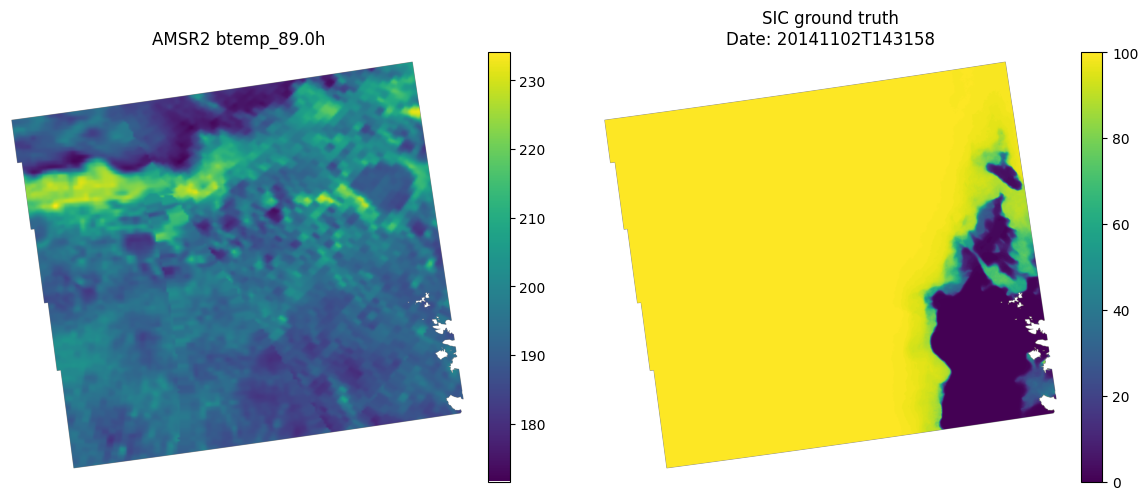

In [130]:
amsr_data = ds_amsr['frequencies']['btemp_89.0h']
sic_data  = ds_sic['band']['band_1']

# Upsample AMSR2 to SIC size
from scipy.ndimage import zoom
zoom_factors = (sic_data.shape[0] / amsr_data.shape[0],
                sic_data.shape[1] / amsr_data.shape[1])
amsr_upsampled = zoom(amsr_data, zoom_factors, order=1)

# Mask: nodata is 255 or nan
nodata_mask = (sic_data == 255) | np.isnan(sic_data)
amsr_masked = np.where(nodata_mask, np.nan, amsr_upsampled)
sic_masked  = np.where(nodata_mask, np.nan, sic_data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(amsr_masked, cmap='viridis')
axes[0].set_title('AMSR2 btemp_89.0h')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sic_masked, cmap='viridis', vmin=0, vmax=100)
axes[1].set_title(f"SIC ground truth\nDate: {ds_sic['time']}")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#### Sample data plots

In [108]:
train_csv = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/training_index.csv'
df_train = pd.read_csv(train_csv)

In [ ]:
print(f'Total sampled matches: {len(df_train)}')

Total sampled matches: 47122


(-5000000.0, 3000000.0)

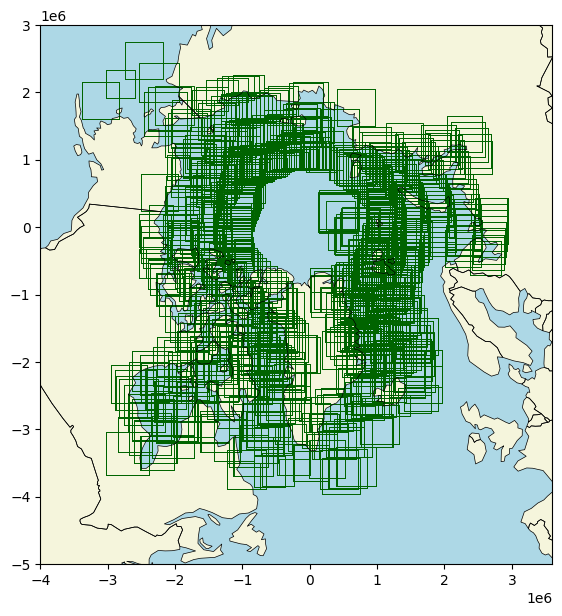

In [ ]:
import geopandas as gpd
from shapely.geometry import box, Polygon
def bbox_to_polygon(bbox_str):
    minx, miny, maxx, maxy = ast.literal_eval(bbox_str)
    return box(minx, miny, maxx, maxy)

### plotting in another epsg (polar stereographic) so we avoid the distortion of the footprints that go over the dateline
df_train['geometry'] = df['bbox'].apply(lambda s: box(*ast.literal_eval(s)))

gdf = gpd.GeoDataFrame(df_train, geometry='geometry', crs="EPSG:3411")

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('lightblue')

world = gpd.read_file('/dmidata/projects/asip-cms/code/sentinel1_download/flood_data/ne_110m_admin_0_countries.shp')
world = world[world['SOVEREIGNT'] != 'Antarctica']
# Plot the world map
world.to_crs(epsg=3411).plot(ax=ax, color='beige')
world.boundary.to_crs(epsg=3411).plot(ax=ax, color='black', linewidth=0.5, zorder=3)

# Plot the arctic polygons
#western_arctic_gdf.boundary.to_crs(epsg=3411).plot(ax=ax, color='blue', zorder=3)
#eastern_arctic_gdf.boundary.to_crs(epsg=3411).plot(ax=ax, color='red', zorder=3)


# Plot the convex hulls of the S1 products
# gdf.to_crs(epsg=3411).plot(ax=ax, color='green', alpha=0.3, zorder=2)
gdf.boundary.to_crs(epsg=3411).plot(ax=ax, color='darkgreen', linewidth=0.7, zorder=2)

# title
# plt.title('Sentinel-1 scenes', fontsize=12)

# Set the plot limits
ax.set_xlim(-4e6, 3.6e6)
ax.set_ylim(-5e6, 3e6)

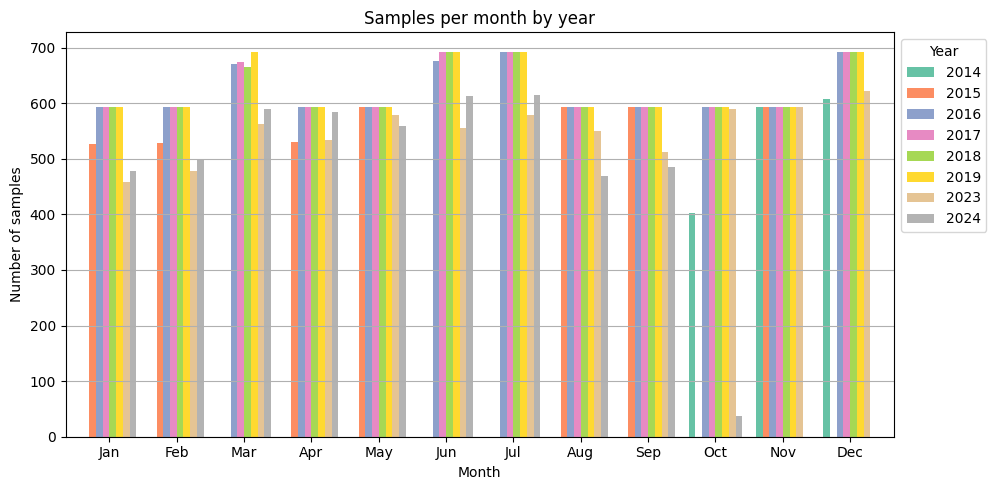

In [120]:
fig, ax = plt.subplots(figsize=(10, 5))

df_train.groupby(['year', 'month']).size().unstack(level=0).plot(
    kind='bar', ax=ax, colormap='Set2', width=0.8
)
ax.grid(axis='y')
ax.set_xlabel('Month')
ax.set_ylabel('Number of samples')
ax.set_title('Samples per month by year')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.legend(title='Year', bbox_to_anchor=(1.12,1), loc='upper right')


plt.tight_layout()
plt.show()

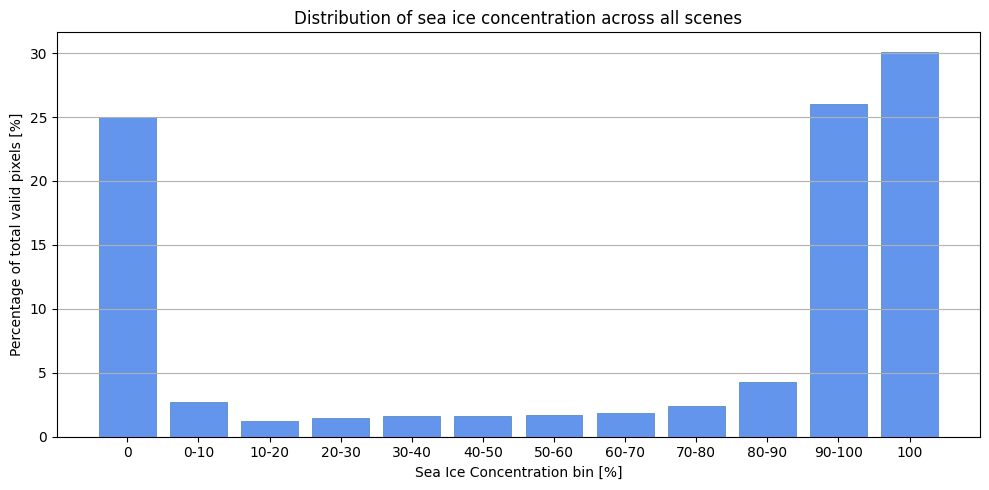

In [121]:
bins = ['val_0', '0-10', '10-20', '20-30', '30-40', '40-50',
        '50-60', '60-70', '70-80', '80-90', '90-100', 'val_100']

# Calculate percentage of total pixels for each bin
bin_totals = df_train[bins].sum()
bin_pct = bin_totals / bin_totals.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(bins)), bin_pct, color='cornflowerblue', edgecolor='steelblue', linewidth=0.5)

ax.set_xticks(range(len(bins)))
ax.set_xticklabels(['0', '0-10', '10-20', '20-30', '30-40', '40-50',
                    '50-60', '60-70', '70-80', '80-90', '90-100', '100'], rotation=0)
ax.set_xlabel('Sea Ice Concentration bin [%]')
ax.set_ylabel('Percentage of total valid pixels [%]')
ax.set_title('Distribution of sea ice concentration across all scenes')
plt.grid(axis='y')

plt.tight_layout()
plt.show()